# Finding Steady states

Searching steady states in RTG model `rtgMTK` using `find_steady_states()` in `RetroSignalModel.jl` module.

In [1]:
using RetroSignalModel
using ModelingToolkit

┌ Info: Precompiling RetroSignalModel [8bac15de-65a1-44a4-8b6e-7c4bf648ff0c]
└ @ Base loading.jl:1662


In [2]:
paramsets = load_parameters("solution_rtgM4.csv");

In [3]:
srange = 0.0:0.05:1.0
nsols = 100
paramidx = 1

1

In [4]:
sols = map(srange) do s
    find_steady_states(;S = t -> s, params=paramsets[paramidx], trajectories=nsols)
end

length.(sols)

21-element Vector{Int64}:
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1

The system has one steady-state for each signal strength.

## Visualization

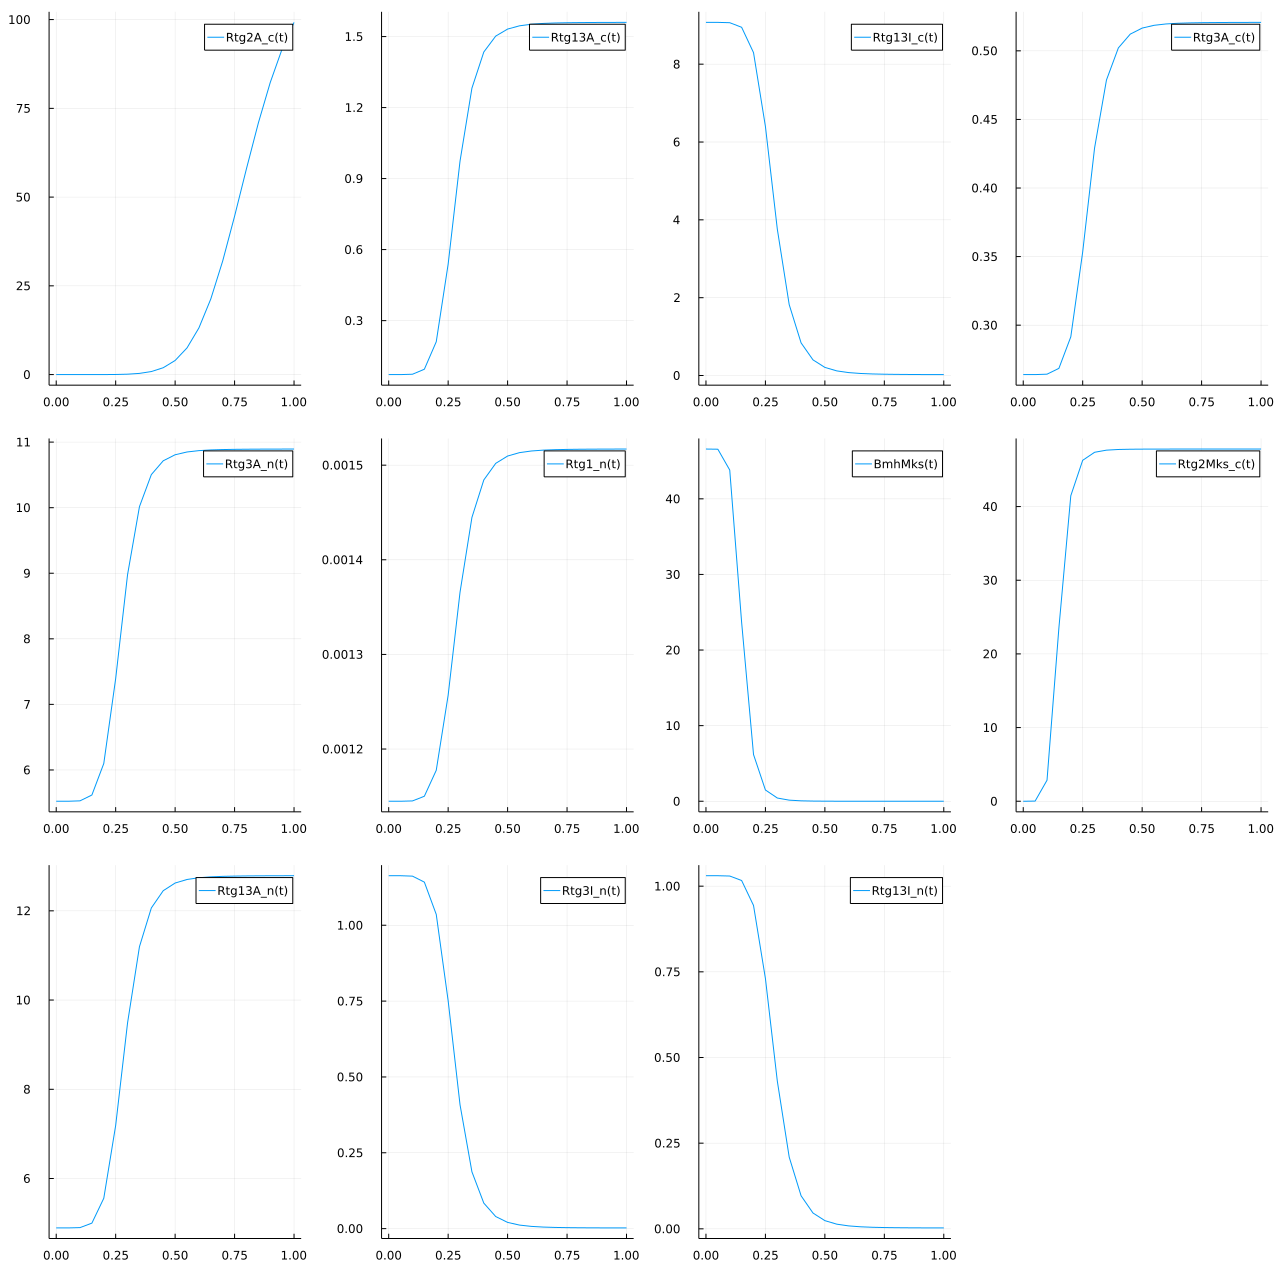

In [5]:
using Plots
import RetroSignalModel as rs

sts = states(rs.RtgMTK(;name=:sys))

pls = map(keys(sts)) do i
    xs = srange
    ys = getindex.(first.(sols), i)
    plot(xs, ys, lab=string(sts[i]))
end

plot(pls..., size=(1280, 1280))